# Weekly report — 2026-05-20

## Part 1 — Matrix-generation storage problem

The current `ball_rollers` matrix-generation pipeline runs **all 30 steps to disk first, then random-samples 30 pairs and deletes the rest**. This doesn't fit on disk for large meshes.

### Evidence — the 705 984-vertex mesh

A single mesh of this size has already used **214 GB** and is **only at step 17 of 30**.

| metric | value |
|---|---:|
| mesh size | 705 984 vertices |
| one `A.bin` | **1.43 GB** |
| matrices on disk so far | 248 |
| steps completed | **17 / 30** |
| disk used | **214 GB** |
| projected at 30/30 | **≈ 378 GB** *(214 × 30/17)* |

For context, `/mnt/hdd1` is 15 TB total and currently 95 % full (~703 GB free). This one mesh alone would consume more than half of all remaining free space before the sampler ever runs — and we have many more meshes queued, several of them larger than 705 984.

Folder: `/mnt/hdd1/chenyang/benchmark_data/larger_matrix_exp/ball_rollers/result_10000-2568220-small-small-resume/705984/`

In [17]:
# Reproduce the 705 984 numbers from disk
import os, subprocess

FOLDER = '/mnt/hdd1/chenyang/benchmark_data/larger_matrix_exp/ball_rollers/result_10000-2568220-small-small-resume/705984'

a_bins = [f for f in os.listdir(FOLDER) if f.endswith('_A.bin')]
steps = {f.split('_')[0] for f in a_bins}
sizes = sorted(os.path.getsize(os.path.join(FOLDER, f)) for f in a_bins if os.path.getsize(os.path.join(FOLDER, f)) > 0)
median_gb = sizes[len(sizes) // 2] / 1024**3 if sizes else 0
folder_size = subprocess.check_output(['du', '-sh', FOLDER]).decode().split()[0]

print(f'A.bin count:        {len(a_bins)}')
print(f'unique steps:       {len(steps)} (of 30)')
print(f'median A.bin size:  {median_gb:.2f} GB')
print(f'folder size:        {folder_size}')
print()
print(subprocess.check_output(['df', '-h', '/mnt/hdd1/']).decode())

A.bin count:        248
unique steps:       17 (of 30)
median A.bin size:  1.40 GB
folder size:        214G

Filesystem      Size  Used Avail Use% Mounted on
/dev/sdc1        15T   14T  683G  96% /mnt/hdd1



### Two ways forward

**Option A — per-step sampling (preferred).** After each step finishes, random-sample ~5 % of that step's iterations and delete the rest *before* moving on to the next step. A final pass at the end trims survivors to the global target (30 pairs). Peak disk usage shrinks from "all 30 steps" to "one step's transient + small kept pool" — about **20 GB** for the 705 984 mesh (≈ 10× less).

**Option B — HPC or more disk.** Keep the current design, move generation to a cluster node with larger scratch, or request a quota bump from IT.

Option A is the cheaper fix; B is the fallback if even per-step peaks don't fit.

## Part 2 — `mat_twist` solve-time distribution across steps / iterations

Experiment driver: `test_larger_mat_multithread_no_taskset_mpi_parallel-5-20.py`.
Results: `/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-5-20/mat_twist/mat_twist_8/`.

Two mesh sizes ran (3 146 and 11 629 rows); plot below uses **11 629** (the larger one — 3 146 left as a follow-up).

Solvers shown: AMGCL, Hypre_mpi, Trilinos. `Eigen::PardisoLDLT` is excluded because it is a direct solver and does not report a `num_iterations` count. Style follows `analysis_2026-4-27-explore-steps-iteration.ipynb`: x-axis is `step-iter`, vertical dotted lines mark simulation-step boundaries.

In [18]:
import os, sys, re, contextlib, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

sys.path.insert(0, '/u/1/chenyang/benchmark/analysis')
import libs.parser; importlib.reload(libs.parser)
from libs.parser import parse_log_file

SOLVER_COLORS = {
    'AMGCL':     '#d62728',
    'Hypre_mpi': '#2ca02c',
    'Trilinos':  '#ff7f0e',
}
ITERATIVE = list(SOLVER_COLORS.keys())

BASE = '/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-5-20/mat_twist/mat_twist_8'
MAT_SZ = 11629  # also have 3146; rerun with this changed if needed
DATA_SOURCE_NOTE = f'mat_twist  ·  mat_sz = {MAT_SZ}  ·  OMP=8 / mpirun -np 8'


def load_one(solver, mat_sz):
    lp = os.path.join(BASE, f'{solver}_{mat_sz}.log')
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        entries = parse_log_file(lp, solver)
    rows = []
    for e in entries:
        m = re.search(r'/(\d+)_(\d+)_A\.bin$', e.get('bin_A') or '')
        if not m:
            continue
        rows.append({
            'step': int(m.group(1)),
            'iter': int(m.group(2)),
            'elapse_time':    e.get('elapse_time'),
            'num_iterations': e.get('num_iterations'),
            'solver': solver,
        })
    return pd.DataFrame(rows)


raw = pd.concat([load_one(s, MAT_SZ) for s in ITERATIVE], ignore_index=True)

# Shared integer x-axis over the union of (step, iter) pairs seen across all solvers
unique_keys = (raw[['step', 'iter']]
               .drop_duplicates()
               .sort_values(['step', 'iter'])
               .reset_index(drop=True))
unique_keys['x'] = range(len(unique_keys))
key_to_x = {(s, i): x for s, i, x in zip(unique_keys['step'], unique_keys['iter'], unique_keys['x'])}
raw['x'] = [key_to_x[(s, i)] for s, i in zip(raw['step'], raw['iter'])]
step_start = unique_keys.groupby('step')['x'].min().to_dict()

print(raw.groupby('solver').agg(entries=('elapse_time', 'size'),
                                 step_min=('step', 'min'),
                                 step_max=('step', 'max'),
                                 t_mean=('elapse_time', 'mean'),
                                 t_max=('elapse_time', 'max')))
print(f'\nshared x-axis: {len(unique_keys)} unique (step, iter) pairs, steps '
      f'{unique_keys.step.min()}-{unique_keys.step.max()}')

           entries  step_min  step_max    t_mean    t_max
solver                                                   
AMGCL         1314         1        34  2.008192  3.63490
Hypre_mpi      290         1        31  0.790909  0.97521
Trilinos      1313         1        34  3.113865  4.85410

shared x-axis: 1314 unique (step, iter) pairs, steps 1-34


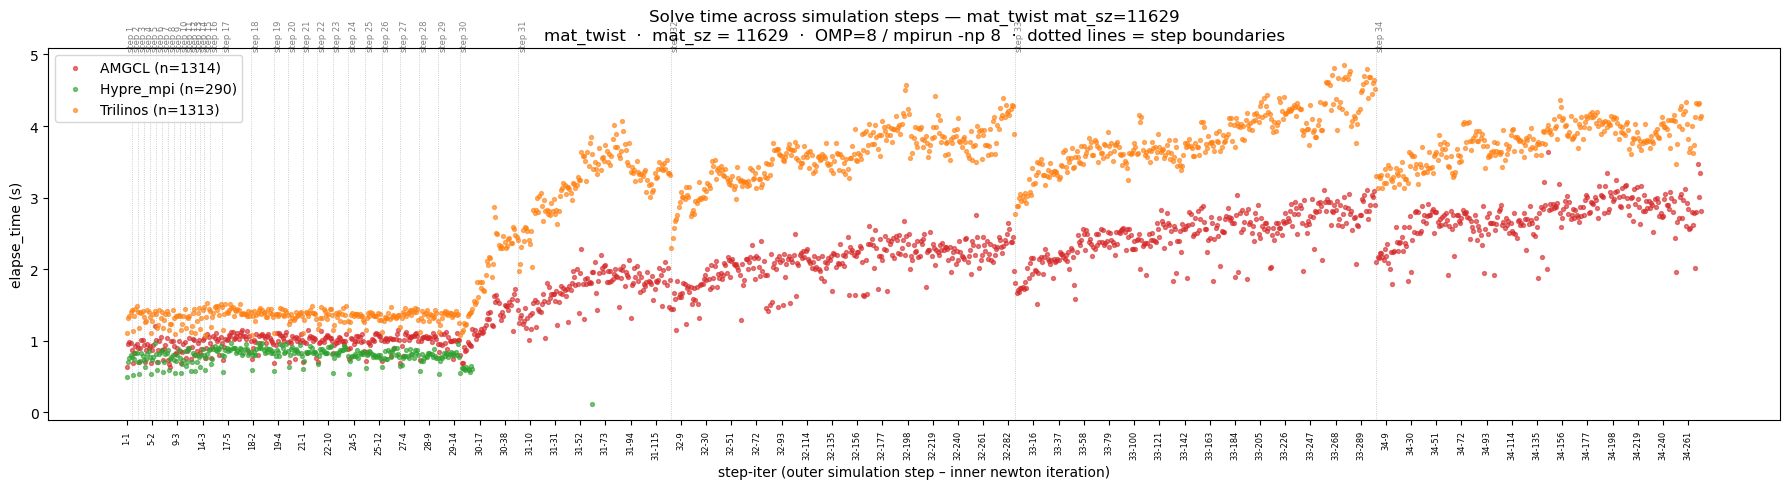

In [19]:
def _decorate_step_axis(ax, ymax):
    for s in sorted(step_start.keys())[1:]:
        ax.axvline(step_start[s] - 0.5, color='grey', linestyle=':', linewidth=0.6, alpha=0.5)
    for s, x0 in step_start.items():
        ax.text(x0, ymax * 1.04, f'step {s}', fontsize=6, rotation=90,
                ha='left', va='bottom', color='grey')
    stride = max(1, len(unique_keys) // 60)
    tick_pos = list(unique_keys['x'][::stride])
    tick_lbl = [f"{unique_keys['step'].iat[i]}-{unique_keys['iter'].iat[i]}"
                for i in range(0, len(unique_keys), stride)]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbl, rotation=90, fontsize=6)


# Combined plot — all 3 iterative solvers on one axis
fig, ax = plt.subplots(figsize=(18, 5))
for solver in ITERATIVE:
    g = raw[raw['solver'] == solver]
    ax.scatter(g['x'], g['elapse_time'], s=8, color=SOLVER_COLORS[solver], alpha=0.6,
               label=f'{solver} (n={len(g)})')

_decorate_step_axis(ax, raw['elapse_time'].max())
ax.set_xlabel('step-iter (outer simulation step – inner newton iteration)')
ax.set_ylabel('elapse_time (s)')
ax.set_title(f'Solve time across simulation steps — mat_twist mat_sz={MAT_SZ}\n'
             f'{DATA_SOURCE_NOTE}  ·  dotted lines = step boundaries')
# ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Per-solver split — easier to read

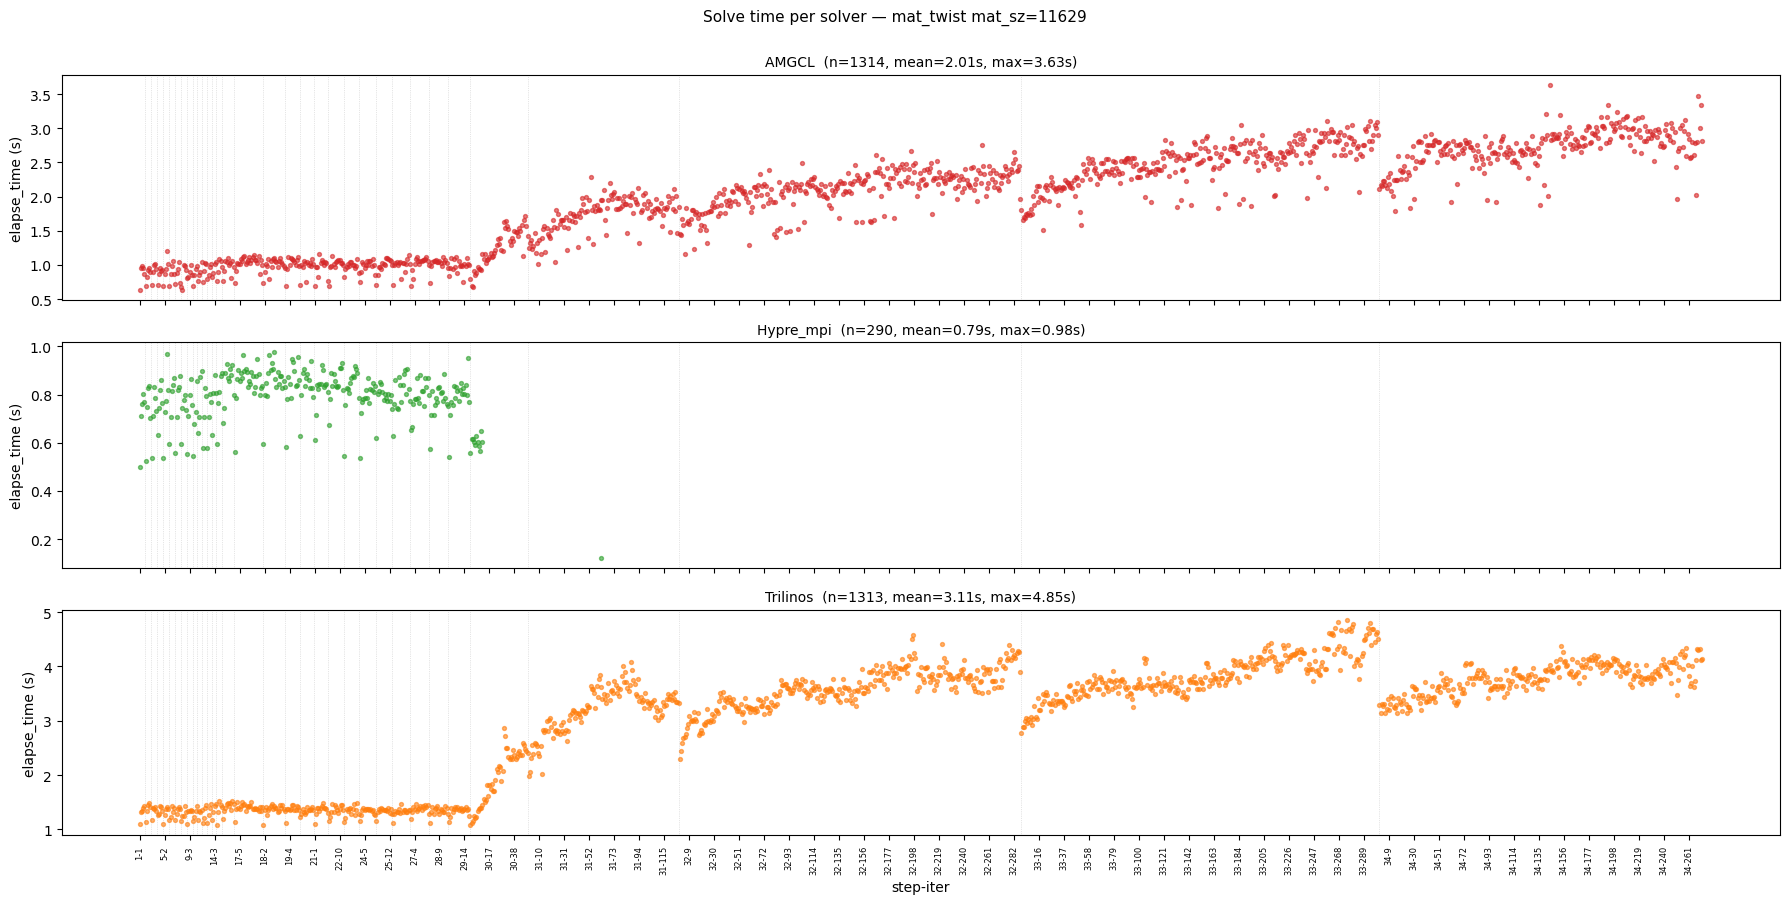

In [20]:
fig, axes = plt.subplots(len(ITERATIVE), 1, figsize=(18, 3.0 * len(ITERATIVE)), sharex=True)
for ax, solver in zip(axes, ITERATIVE):
    color = SOLVER_COLORS[solver]
    g = raw[raw['solver'] == solver]
    ax.scatter(g['x'], g['elapse_time'], s=8, color=color, alpha=0.6)
    for s in sorted(step_start.keys())[1:]:
        ax.axvline(step_start[s] - 0.5, color='grey', linestyle=':', linewidth=0.5, alpha=0.4)
    ax.set_title(f'{solver}  (n={len(g)}, mean={g.elapse_time.mean():.2f}s, '
                 f'max={g.elapse_time.max():.2f}s)', fontsize=10)
    ax.set_ylabel('elapse_time (s)')
#     ax.grid(True, alpha=0.25)

stride = max(1, len(unique_keys) // 60)
tick_pos = list(unique_keys['x'][::stride])
tick_lbl = [f"{unique_keys['step'].iat[i]}-{unique_keys['iter'].iat[i]}"
            for i in range(0, len(unique_keys), stride)]
axes[-1].set_xticks(tick_pos)
axes[-1].set_xticklabels(tick_lbl, rotation=90, fontsize=6)
axes[-1].set_xlabel('step-iter')

fig.suptitle(f'Solve time per solver — mat_twist mat_sz={MAT_SZ}', fontsize=11, y=1.0)
plt.tight_layout()
plt.show()

### Why does Hypre have so few points?

In the plots above, Hypre shows ~290 entries while AMGCL and Trilinos show ~1314 each.
**Hypre actually ran all 1314 matrices** — the difference comes from the parser silently
dropping runs whose log block contains the substring `error`.

Hypre prints

```
hypre error in file ".../krylov/pcg.c", line 709, error code = 256 - Subnormal gamma value in PCG
```

on the harder mat_twist matrices, so those runs get filtered out. But this is not just a
parser issue — those runs **failed to converge**:

| | n | median residual |
|---|---:|---:|
| Hypre runs the parser keeps (no warning) | 290 | **1.66 × 10⁻¹⁵** ✅ |
| Hypre runs the parser drops (warning) | 1024 | **9.67 × 10⁻³** ❌ |

#### What "Subnormal gamma value in PCG" means

PCG computes a scalar `gamma = (r, M⁻¹r)` each iteration. When `gamma` underflows into
the IEEE 754 **subnormal** range (< 2.2 × 10⁻³⁰⁸), arithmetic on it becomes unreliable
and the algorithm bails out early. **This is not an iteration-count problem** — PCG
voluntarily quits after a handful of steps, far below `solver_maxiter = 1000`.

The mat_twist matrices are ill-conditioned (the twist deformation drives the stiffness
matrix toward a near-rigid-rotation mode → very small eigenvalues), so the preconditioned
inner product collapses to subnormal before convergence.

**Important nuance:** the same matrices solve fine under AMGCL and Trilinos, so they
are **not unsolvable** — Hypre's PCG + BoomerAMG combination is just not robust on this
particular geometry. It's an algorithmic-fit issue, not a problem-difficulty wall.

The next cell loads the *dropped* runs with a temporary inline parser (not modifying
`libs/parser.py`) so we can see directly that the failed runs have **low**
`num_iterations`, not high — confirming early breakdown rather than running out of budget.

In [21]:
# Inline lenient parser — used ONLY here, to recover the runs the vanilla parser
# silently drops (i.e. blocks that contain the word "error"). Does NOT modify
# libs/parser.py.

_ANSI = re.compile(r'\x1b\[[0-9;]*m')

def _parse_lenient(log_path, solver):
    """Yield one dict per [EXPBEGIN]...[EXPEND] block, with a 'converged' flag.

    converged == False  ⇔  block contains 'hypre error' / 'ERROR' / 'TIMEOUT' / etc.
    """
    with open(log_path) as f:
        lines = f.readlines()
    b_idxs = [i for i, l in enumerate(lines) if '[EXPBEGIN]' in l]
    e_idxs = [i for i, l in enumerate(lines) if '[EXPEND]'   in l]
    err_terms = ('hypre error', 'ERROR', 'TIMEOUT')

    for b, e in zip(b_idxs, e_idxs):
        block = lines[b:e + 1]
        text  = ''.join(block)
        converged = not any(t in text for t in err_terms)

        # Walk backwards for the mpirun line carrying _A.bin
        bin_A = None
        for j in range(b - 1, max(b - 50, -1), -1):
            if '_A.bin' in lines[j]:
                for part in lines[j].split():
                    if '_A.bin' in part:
                        bin_A = part.strip()
                        break
                break
        if bin_A is None:
            continue
        m = re.search(r'/(\d+)_(\d+)_A\.bin$', bin_A)
        if not m:
            continue

        out = {
            'step': int(m.group(1)),
            'iter': int(m.group(2)),
            'solver': solver,
            'converged': converged,
        }
        for line in block:
            l = _ANSI.sub('', line)
            for pat, kfn in [
                (r'\[timing\] (\w+) ([\d.eE+\-]+)s', lambda m: (m.group(1), float(m.group(2)))),
                (r'\[non_stopwatch_timing\] (\w+) ([\d.eE+\-]+)s', lambda m: (m.group(1), float(m.group(2)))),
                (r'\[stats\] (\w+) ([\d.eE+\-]+)', lambda m: (m.group(1), float(m.group(2)))),
            ]:
                mm = re.search(pat, l)
                if mm:
                    try:
                        k, v = kfn(mm)
                        out[k] = v
                    except ValueError:
                        pass
        yield out


HYPRE_LOG = os.path.join(BASE, f'Hypre_mpi_{MAT_SZ}.log')
hypre_full = pd.DataFrame(_parse_lenient(HYPRE_LOG, 'Hypre_mpi'))
hypre_full['x'] = [key_to_x.get((s, i)) for s, i in zip(hypre_full['step'], hypre_full['iter'])]
# Drop any rows whose (step, iter) isn't on the shared x-axis (none expected, but safe)
hypre_full = hypre_full[hypre_full['x'].notna()].copy()

print(f'Hypre runs total (lenient):       {len(hypre_full)}')
print(f'  converged (parser kept):        {(hypre_full.converged == True).sum()}')
print(f'  PCG broke down (parser dropped): {(hypre_full.converged == False).sum()}')
print()
print('num_iterations by group:')
print(hypre_full.groupby('converged')['num_iterations'].describe()[['count','min','50%','mean','max']])
print()
print('residual by group:')
print(hypre_full.groupby('converged')['residual'].describe()[['count','min','50%','mean','max']])

Hypre runs total (lenient):       1314
  converged (parser kept):        290
  PCG broke down (parser dropped): 1024

num_iterations by group:
            count  min    50%        mean    max
converged                                       
False      1024.0  1.0    3.0    2.937500   42.0
True        290.0  3.0  334.0  318.237931  364.0

residual by group:
            count           min           50%      mean       max
converged                                                        
False      1024.0  3.723200e-06  9.665400e-03  0.050705  0.269710
True        290.0  3.889500e-17  1.657500e-15  0.000103  0.029747


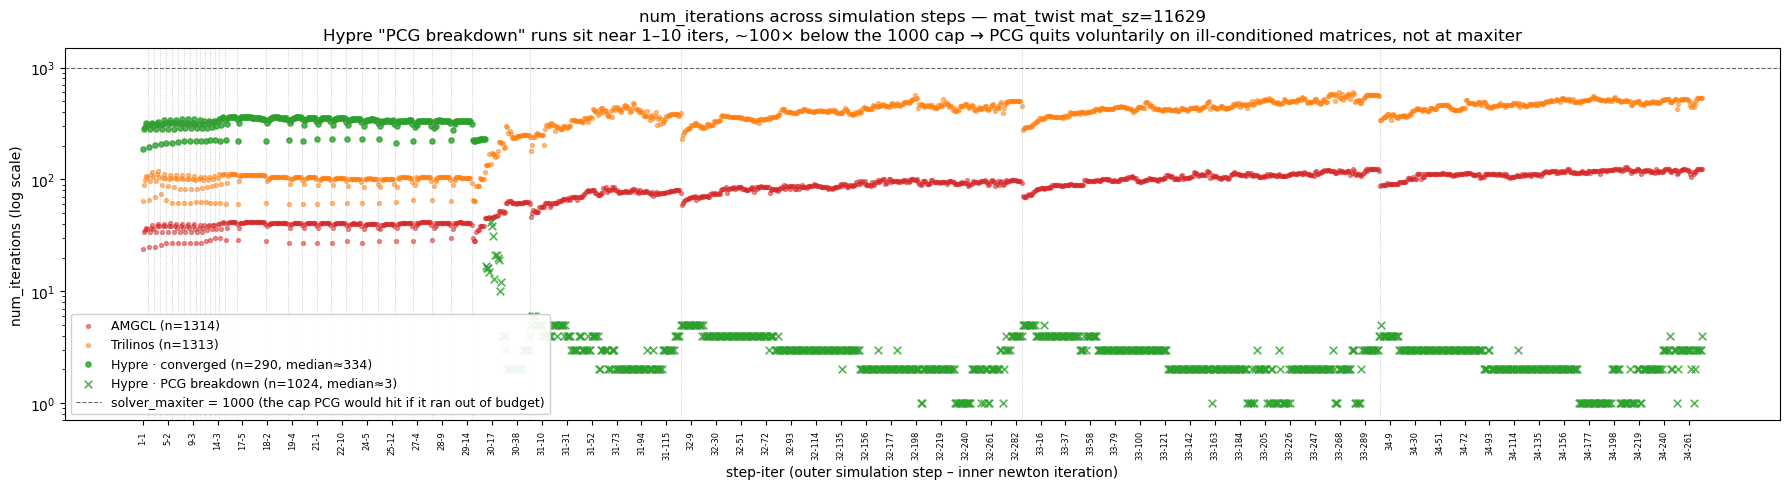


Hypre converged:        median num_iter = 334, median residual = 1.66e-15
Hypre PCG-breakdown:    median num_iter = 3, median residual = 9.67e-03
  → broken runs never approach maxiter=1000; they exit after a handful of steps.


In [22]:
# num_iterations vs step-iter — Hypre's failed runs marked separately
# Log y-axis so the two Hypre populations (converged ~300, broken ~3) are both visible.
fig, ax = plt.subplots(figsize=(18, 5))

for solver in ['AMGCL', 'Trilinos']:
    g = raw[raw['solver'] == solver]
    ax.scatter(g['x'], g['num_iterations'], s=8, color=SOLVER_COLORS[solver], alpha=0.5,
               label=f'{solver} (n={len(g)})')

hg_ok  = hypre_full[hypre_full['converged']]
hg_bad = hypre_full[~hypre_full['converged']]
ax.scatter(hg_ok['x'],  hg_ok['num_iterations'],
           s=14, color=SOLVER_COLORS['Hypre_mpi'], alpha=0.8, marker='o',
           label=f'Hypre · converged (n={len(hg_ok)}, median≈{int(hg_ok.num_iterations.median())})')
ax.scatter(hg_bad['x'], hg_bad['num_iterations'],
           s=30, color=SOLVER_COLORS['Hypre_mpi'], alpha=0.8, marker='x', linewidths=1.2,
           label=f'Hypre · PCG breakdown (n={len(hg_bad)}, median≈{int(hg_bad.num_iterations.median())})')

ax.axhline(1000, color='black', linestyle='--', linewidth=0.8, alpha=0.6,
           label='solver_maxiter = 1000 (the cap PCG would hit if it ran out of budget)')
ax.set_yscale('log')
ax.set_ylim(0.7, 1500)

for s in sorted(step_start.keys())[1:]:
    ax.axvline(step_start[s] - 0.5, color='grey', linestyle=':', linewidth=0.6, alpha=0.5)

stride = max(1, len(unique_keys) // 60)
tick_pos = list(unique_keys['x'][::stride])
tick_lbl = [f"{unique_keys['step'].iat[i]}-{unique_keys['iter'].iat[i]}"
            for i in range(0, len(unique_keys), stride)]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, rotation=90, fontsize=6)

ax.set_xlabel('step-iter (outer simulation step – inner newton iteration)')
ax.set_ylabel('num_iterations (log scale)')
ax.set_title(f'num_iterations across simulation steps — mat_twist mat_sz={MAT_SZ}\n'
             f'Hypre "PCG breakdown" runs sit near 1–10 iters, ~100× below the 1000 cap → '
             f'PCG quits voluntarily on ill-conditioned matrices, not at maxiter')
ax.legend(loc='lower left', fontsize=9, framealpha=0.92)
plt.tight_layout()
plt.show()

print(f'\nHypre converged:        median num_iter = {hg_ok.num_iterations.median():.0f}, '
      f'median residual = {hg_ok.residual.median():.2e}')
print(f'Hypre PCG-breakdown:    median num_iter = {hg_bad.num_iterations.median():.0f}, '
      f'median residual = {hg_bad.residual.median():.2e}')
print('  → broken runs never approach maxiter=1000; they exit after a handful of steps.')

---

## Same analysis — `mat_sz = 3146`

Re-run the three plots above on the smaller mesh (3 146 rows). Same x-axis convention
(`step-iter`, dotted step dividers), same solvers, same Hypre breakdown analysis using
the inline lenient parser.

In [23]:
# Load 3146 data + build shared x-axis (mirrors the 11629 setup cell, suffixed with _b)
MAT_SZ_b = 3146
raw_b = pd.concat([load_one(s, MAT_SZ_b) for s in ITERATIVE], ignore_index=True)

unique_keys_b = (raw_b[['step', 'iter']]
                 .drop_duplicates()
                 .sort_values(['step', 'iter'])
                 .reset_index(drop=True))
unique_keys_b['x'] = range(len(unique_keys_b))
key_to_x_b = {(s, i): x for s, i, x in zip(unique_keys_b['step'], unique_keys_b['iter'], unique_keys_b['x'])}
raw_b['x'] = [key_to_x_b[(s, i)] for s, i in zip(raw_b['step'], raw_b['iter'])]
step_start_b = unique_keys_b.groupby('step')['x'].min().to_dict()

print(raw_b.groupby('solver').agg(entries=('elapse_time', 'size'),
                                   step_min=('step', 'min'),
                                   step_max=('step', 'max'),
                                   t_mean=('elapse_time', 'mean'),
                                   t_max=('elapse_time', 'max')))
print(f'\nshared x-axis: {len(unique_keys_b)} unique (step, iter) pairs, steps '
      f'{unique_keys_b.step.min()}-{unique_keys_b.step.max()}')

           entries  step_min  step_max    t_mean    t_max
solver                                                   
AMGCL         4413         1        72  1.212075  3.18410
Hypre_mpi      271         1        33  0.286203  0.38678
Trilinos      4186         1        69  1.079884  1.71390

shared x-axis: 4416 unique (step, iter) pairs, steps 1-72


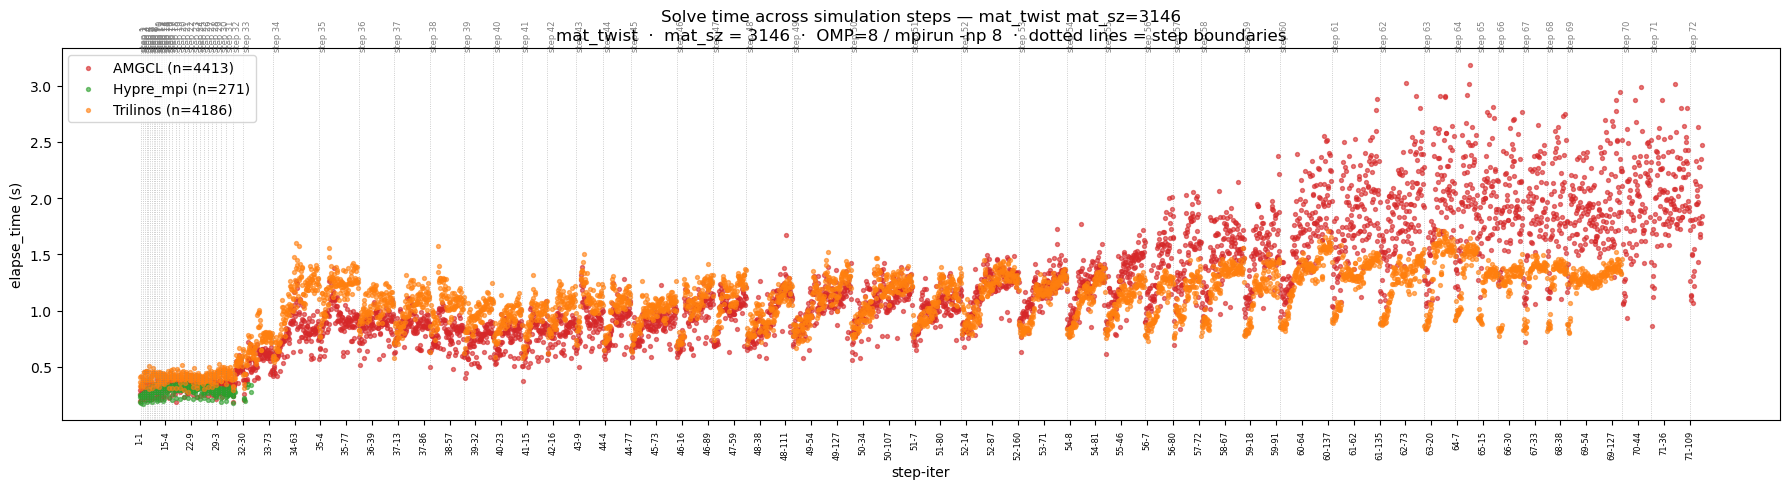

In [24]:
# Combined elapse_time plot — 3146
fig, ax = plt.subplots(figsize=(18, 5))
for solver in ITERATIVE:
    g = raw_b[raw_b['solver'] == solver]
    ax.scatter(g['x'], g['elapse_time'], s=8, color=SOLVER_COLORS[solver], alpha=0.6,
               label=f'{solver} (n={len(g)})')

for s in sorted(step_start_b.keys())[1:]:
    ax.axvline(step_start_b[s] - 0.5, color='grey', linestyle=':', linewidth=0.6, alpha=0.5)
ymax = raw_b['elapse_time'].max()
for s, x0 in step_start_b.items():
    ax.text(x0, ymax * 1.04, f'step {s}', fontsize=6, rotation=90,
            ha='left', va='bottom', color='grey')
stride = max(1, len(unique_keys_b) // 60)
tick_pos = list(unique_keys_b['x'][::stride])
tick_lbl = [f"{unique_keys_b['step'].iat[i]}-{unique_keys_b['iter'].iat[i]}"
            for i in range(0, len(unique_keys_b), stride)]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, rotation=90, fontsize=6)

ax.set_xlabel('step-iter')
ax.set_ylabel('elapse_time (s)')
ax.set_title(f'Solve time across simulation steps — mat_twist mat_sz={MAT_SZ_b}\n'
             f'mat_twist  ·  mat_sz = {MAT_SZ_b}  ·  OMP=8 / mpirun -np 8  ·  dotted lines = step boundaries')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

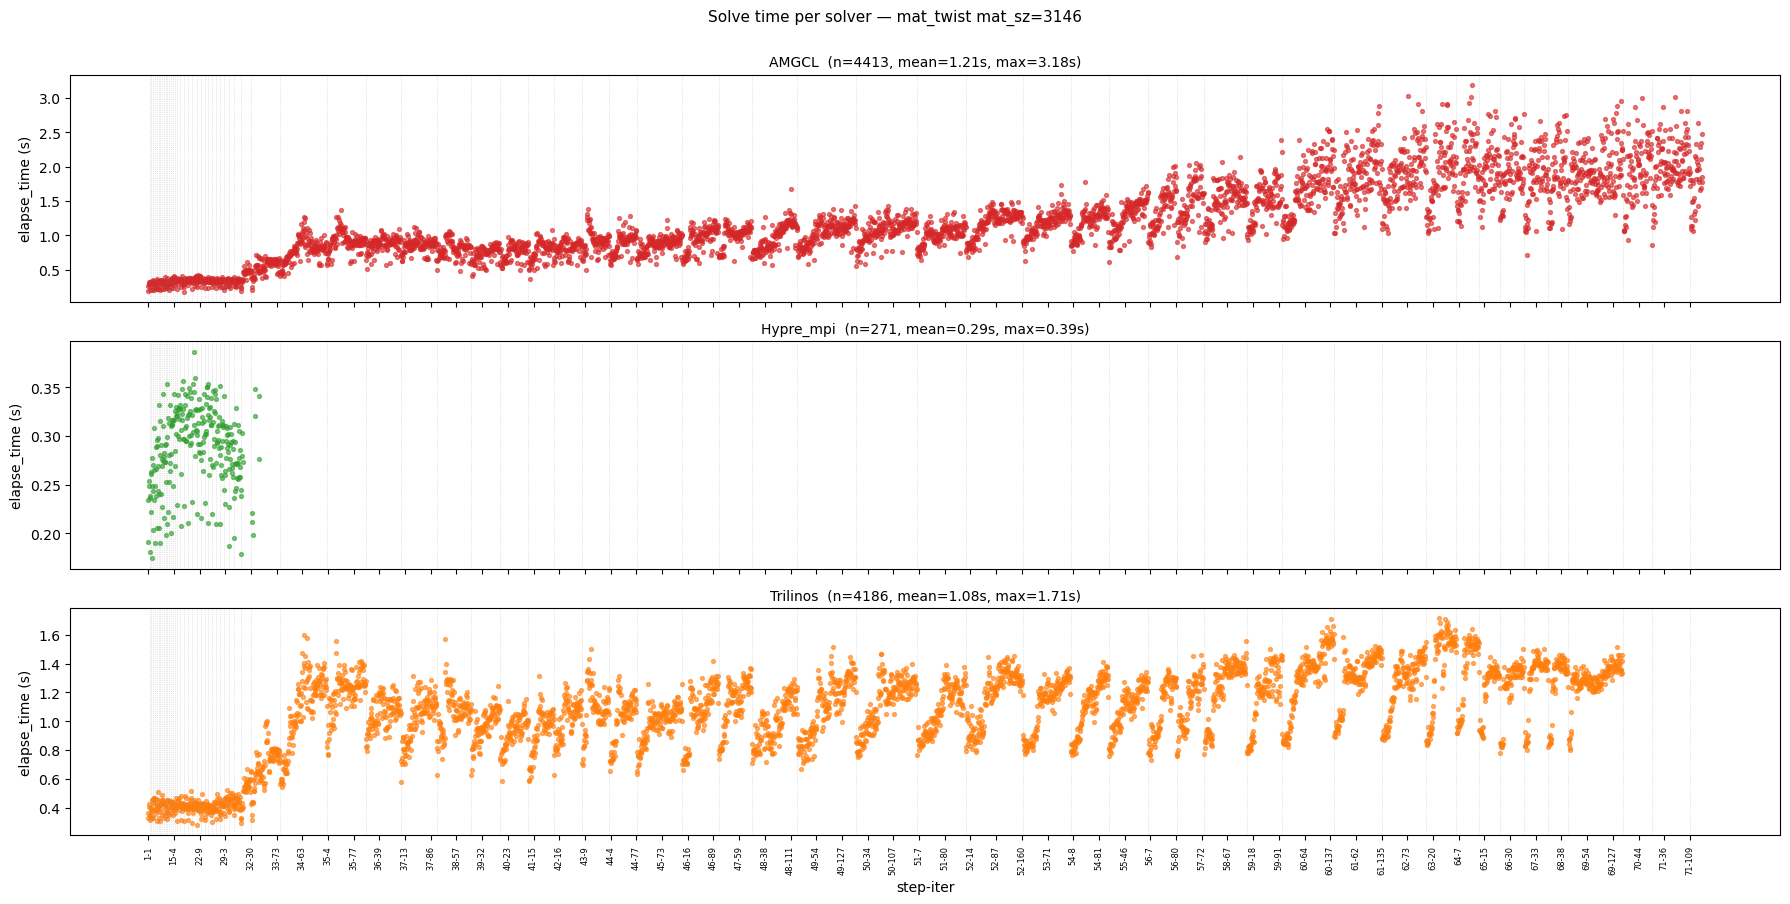

In [25]:
# Per-solver split — 3146
fig, axes = plt.subplots(len(ITERATIVE), 1, figsize=(18, 3.0 * len(ITERATIVE)), sharex=True)
for ax, solver in zip(axes, ITERATIVE):
    color = SOLVER_COLORS[solver]
    g = raw_b[raw_b['solver'] == solver]
    ax.scatter(g['x'], g['elapse_time'], s=8, color=color, alpha=0.6)
    for s in sorted(step_start_b.keys())[1:]:
        ax.axvline(step_start_b[s] - 0.5, color='grey', linestyle=':', linewidth=0.5, alpha=0.4)
    ax.set_title(f'{solver}  (n={len(g)}, mean={g.elapse_time.mean():.2f}s, '
                 f'max={g.elapse_time.max():.2f}s)', fontsize=10)
    ax.set_ylabel('elapse_time (s)')

stride = max(1, len(unique_keys_b) // 60)
tick_pos = list(unique_keys_b['x'][::stride])
tick_lbl = [f"{unique_keys_b['step'].iat[i]}-{unique_keys_b['iter'].iat[i]}"
            for i in range(0, len(unique_keys_b), stride)]
axes[-1].set_xticks(tick_pos)
axes[-1].set_xticklabels(tick_lbl, rotation=90, fontsize=6)
axes[-1].set_xlabel('step-iter')

fig.suptitle(f'Solve time per solver — mat_twist mat_sz={MAT_SZ_b}', fontsize=11, y=1.0)
plt.tight_layout()
plt.show()

Hypre runs total (lenient):       4415
  converged (parser kept):        271
  PCG broke down (parser dropped): 4144


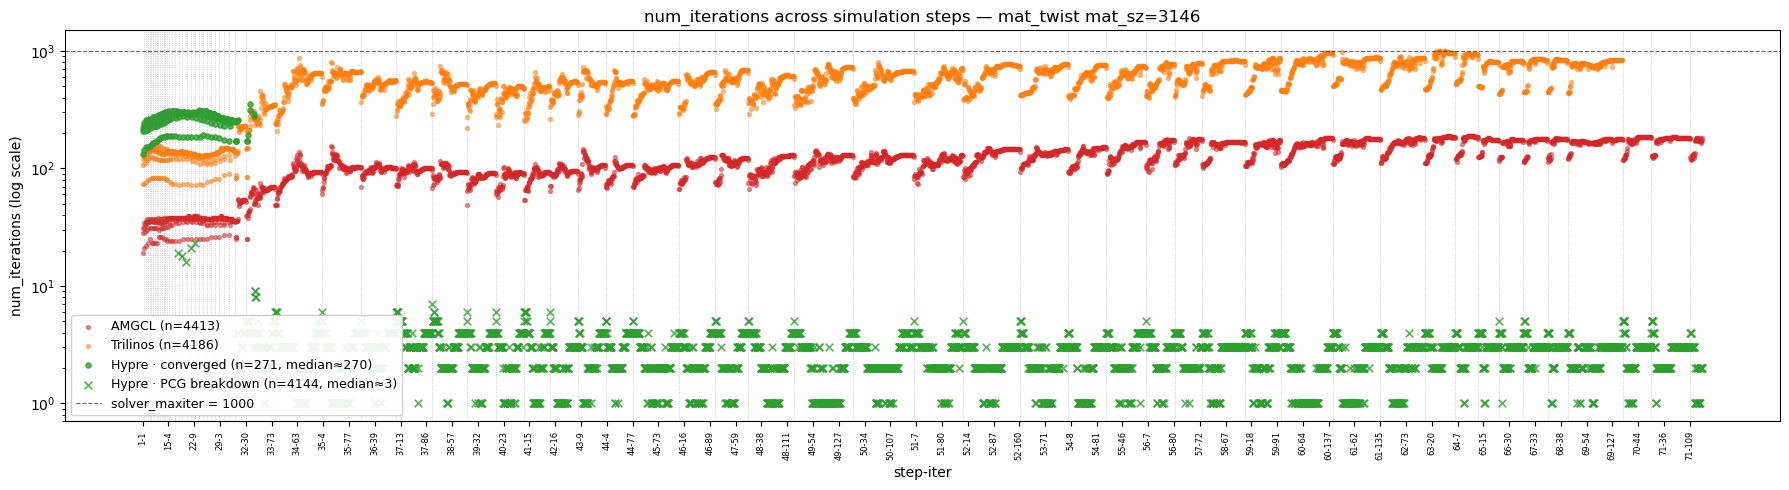


Hypre converged:        median num_iter = 270, median residual = 1.94e-15
Hypre PCG-breakdown:    median num_iter = 3, median residual = 3.34e-03


In [26]:
# Lenient-parser Hypre load + num_iter plot with breakdown — 3146
hypre_full_b = pd.DataFrame(_parse_lenient(os.path.join(BASE, f'Hypre_mpi_{MAT_SZ_b}.log'), 'Hypre_mpi'))
hypre_full_b['x'] = [key_to_x_b.get((s, i)) for s, i in zip(hypre_full_b['step'], hypre_full_b['iter'])]
hypre_full_b = hypre_full_b[hypre_full_b['x'].notna()].copy()

print(f'Hypre runs total (lenient):       {len(hypre_full_b)}')
print(f'  converged (parser kept):        {(hypre_full_b.converged == True).sum()}')
print(f'  PCG broke down (parser dropped): {(hypre_full_b.converged == False).sum()}')

hg_ok_b  = hypre_full_b[hypre_full_b['converged']]
hg_bad_b = hypre_full_b[~hypre_full_b['converged']]

fig, ax = plt.subplots(figsize=(18, 5))
for solver in ['AMGCL', 'Trilinos']:
    g = raw_b[raw_b['solver'] == solver]
    ax.scatter(g['x'], g['num_iterations'], s=8, color=SOLVER_COLORS[solver], alpha=0.5,
               label=f'{solver} (n={len(g)})')

ax.scatter(hg_ok_b['x'],  hg_ok_b['num_iterations'],
           s=14, color=SOLVER_COLORS['Hypre_mpi'], alpha=0.8, marker='o',
           label=f'Hypre · converged (n={len(hg_ok_b)}, median≈{int(hg_ok_b.num_iterations.median()) if len(hg_ok_b) else 0})')
if len(hg_bad_b):
    ax.scatter(hg_bad_b['x'], hg_bad_b['num_iterations'],
               s=30, color=SOLVER_COLORS['Hypre_mpi'], alpha=0.8, marker='x', linewidths=1.2,
               label=f'Hypre · PCG breakdown (n={len(hg_bad_b)}, median≈{int(hg_bad_b.num_iterations.median())})')

ax.axhline(1000, color='black', linestyle='--', linewidth=0.8, alpha=0.6,
           label='solver_maxiter = 1000')
ax.set_yscale('log')
ax.set_ylim(0.7, 1500)

for s in sorted(step_start_b.keys())[1:]:
    ax.axvline(step_start_b[s] - 0.5, color='grey', linestyle=':', linewidth=0.6, alpha=0.5)

stride = max(1, len(unique_keys_b) // 60)
tick_pos = list(unique_keys_b['x'][::stride])
tick_lbl = [f"{unique_keys_b['step'].iat[i]}-{unique_keys_b['iter'].iat[i]}"
            for i in range(0, len(unique_keys_b), stride)]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, rotation=90, fontsize=6)

ax.set_xlabel('step-iter')
ax.set_ylabel('num_iterations (log scale)')
ax.set_title(f'num_iterations across simulation steps — mat_twist mat_sz={MAT_SZ_b}')
ax.legend(loc='lower left', fontsize=9, framealpha=0.92)
plt.tight_layout()
plt.show()

if len(hg_ok_b):
    print(f'\nHypre converged:        median num_iter = {hg_ok_b.num_iterations.median():.0f}, '
          f'median residual = {hg_ok_b.residual.median():.2e}')
if len(hg_bad_b):
    print(f'Hypre PCG-breakdown:    median num_iter = {hg_bad_b.num_iterations.median():.0f}, '
          f'median residual = {hg_bad_b.residual.median():.2e}')